In [3]:
# Create folder
import os

# Create folder
os.makedirs("output_images", exist_ok=True)


In [14]:

import pandas as pd
from sklearn.datasets import load_breast_cancer


data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["Target"] = data.target

print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [22]:
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

# Class Distribution

**Purpose:** Check whether the dataset is balanced or imbalanced.

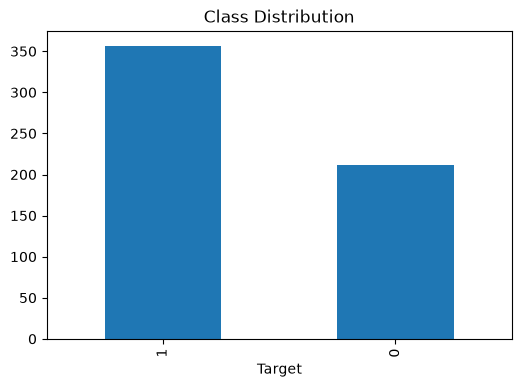

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["Target"].value_counts().plot(kind="bar")

plt.title("Class Distribution")

plt.savefig(
    "output_images/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Histograms

**Purpose:** Understand the distribution of each feature.

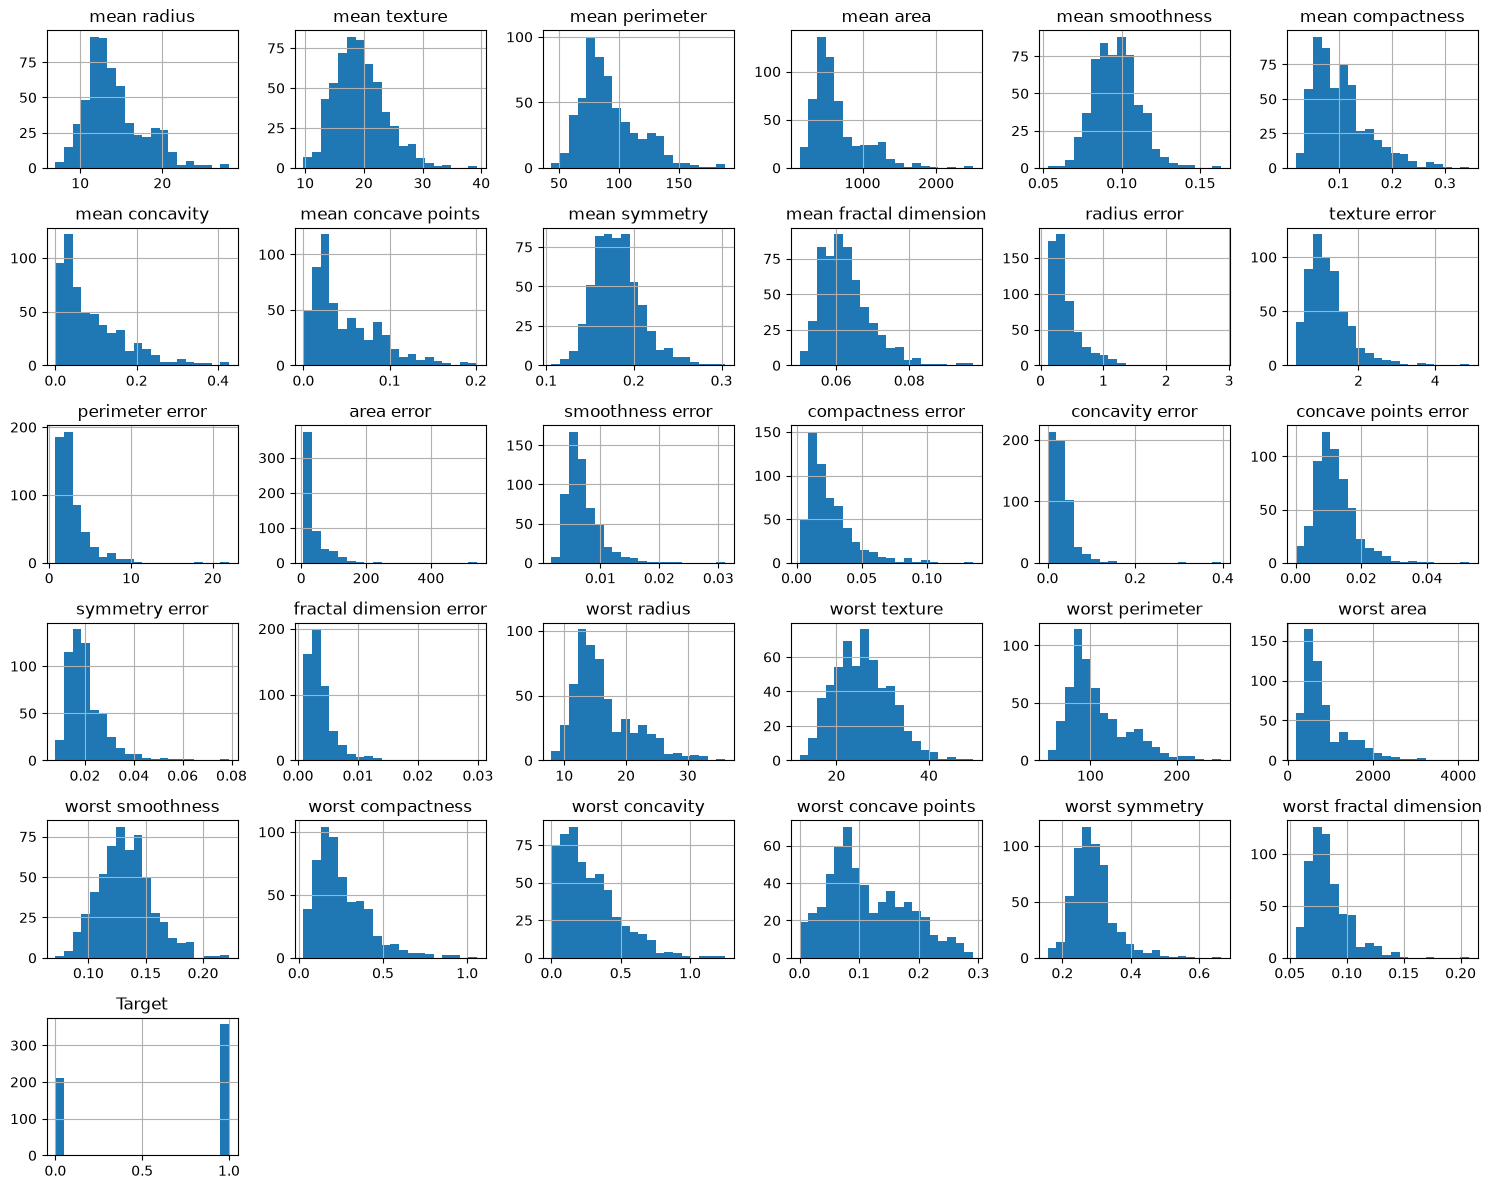

In [19]:
df.hist(figsize=(15,12), bins=20)

plt.tight_layout()

plt.savefig(
    "output_images/feature_histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Boxplots

**Purpose:** Detect outliers in numerical features.

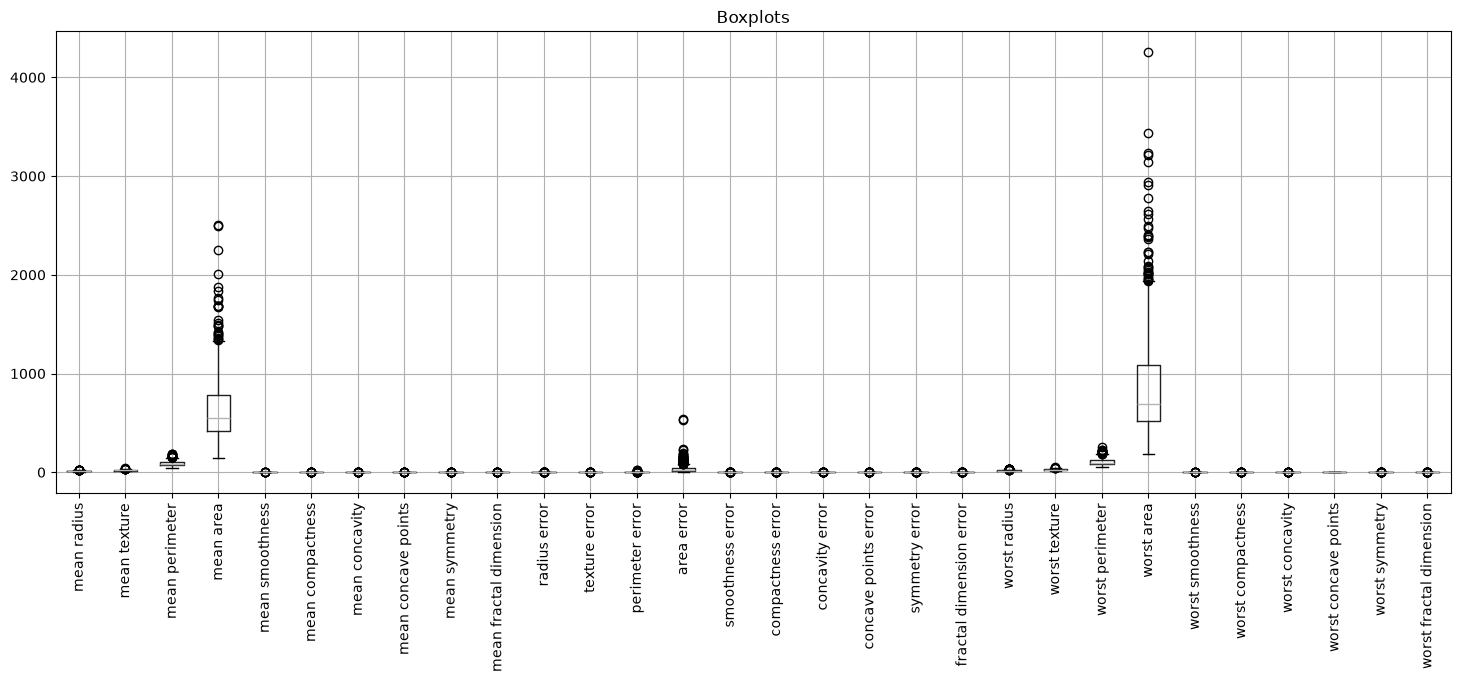

In [21]:
plt.figure(figsize=(18,6))

df.drop("Target", axis=1).boxplot(rot=90)

plt.title("Boxplots")

plt.savefig("output_images/boxplots.png", dpi=300, bbox_inches="tight")

plt.show()

# Correlation Heatmap

**Purpose:** Understand relationships between features.

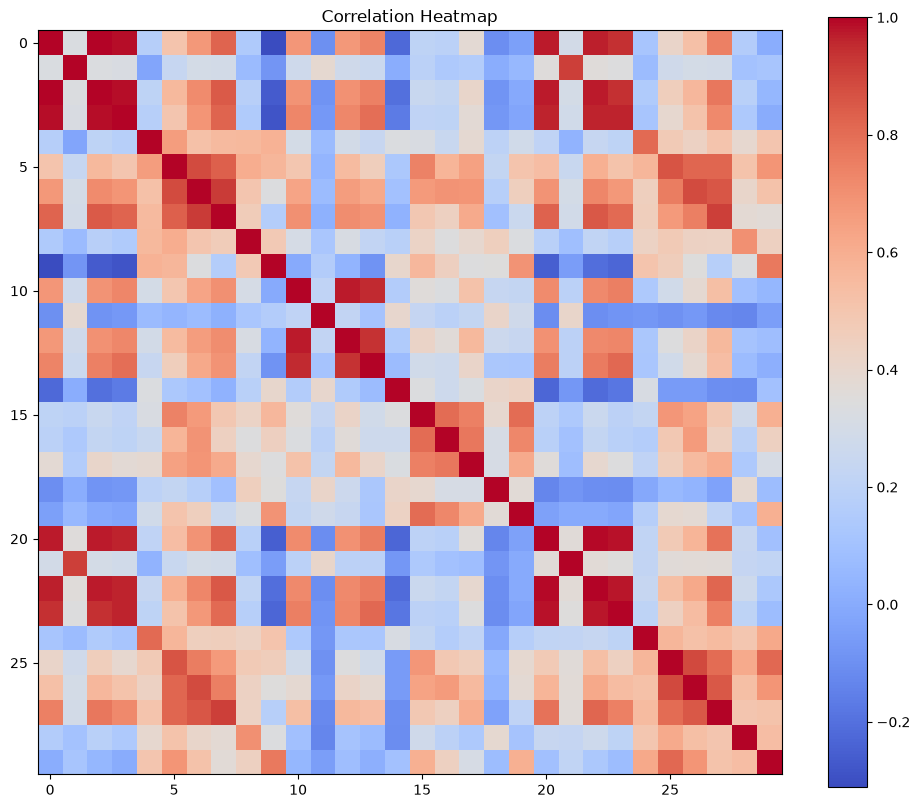

In [24]:

corr = df.drop("Target", axis=1).corr()

plt.figure(figsize=(12,10))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.title("Correlation Heatmap")

plt.savefig("output_images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

# Scatter Plot

**Purpose:** Visualize two features and check if the classes appear linearly separable.

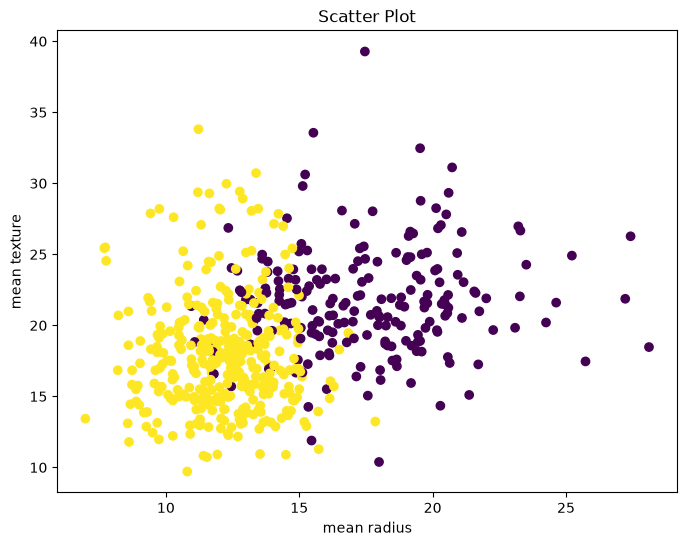

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    df.iloc[:,0],
    df.iloc[:,1],
    c=df["Target"]
)

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])

plt.title("Scatter Plot")

plt.savefig("output_images/scatter_plot.png", dpi=300, bbox_inches="tight")

plt.show()

# PCA Visualization

**Purpose:** Reduce 30 features to 2 dimensions for visualization.

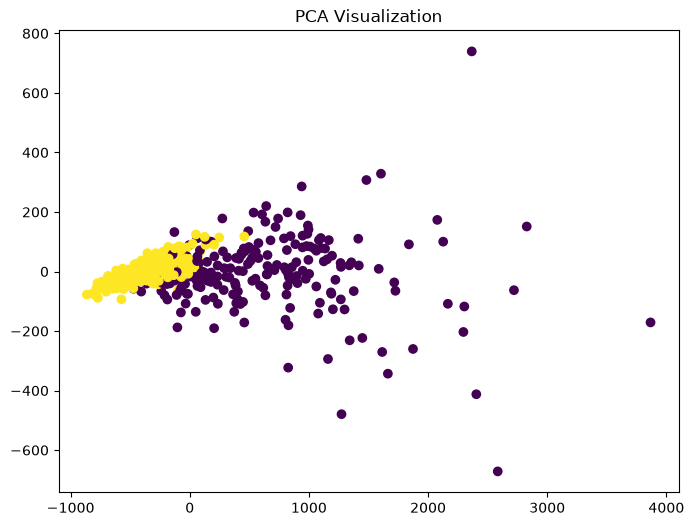

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(data.data)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=data.target
)

plt.title("PCA Visualization")

plt.savefig("output_images/pca_visualization.png", dpi=300, bbox_inches="tight")

plt.show()

# Conclusion

EDA helps us:

- Understand the dataset
- Check missing values
- Detect class imbalance
- Identify outliers
- Analyze feature relationships
- Visualize class separation

**Note:** EDA cannot determine the best SVM kernel. The final kernel should be selected using model evaluation and GridSearchCV.